In [62]:
# Setup
%load_ext autoreload
%autoreload 2

import sys
import os

# Add parent directory to path
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import numpy as np
import matplotlib.pyplot as plt

# Import NEW unified API
from src.dataset import PINNDataset
from src.train_loop import train_pinn
from src.visualization import plot_results, plot_losses

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("✓ Modules loaded successfully")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cpu
✓ Modules loaded successfully


In [63]:
# Choose your dataset:
# Option 1: Calhoun CCZO (6 depths, no WTD)
config_file = '../configs/baseline.yaml'

# Option 2: US-Uaf (5 depths, with WTD)
# config_file = '../configs/us_uaf_2019.yaml'

print("=" * 70)
print("LOADING DATASET FROM YAML")
print("=" * 70)
print(f"Config: {config_file}\n")

# 🚀 ONE LINE to load everything!
dataset = PINNDataset(config_file, verbose=True)

LOADING DATASET FROM YAML
Config: ../configs/baseline.yaml

INITIALIZING PINN DATASET
Config: ../configs/baseline.yaml
Note: Adjusted data path for notebook context: ../data/2017_HalfHourly_UTC_ForestSite1.xlsx


LOADING DATA FROM YAML SPECIFICATION
LOADING SOIL MOISTURE DATA (GENERIC LOADER)
  File format: Excel

Data loaded:
  Total records: 17519
  Time range: 2017-01-01 01:00:00 to 2018-01-01 00:00:00
  Duration: ~364 days
  Resolution: 30 minutes

REPLACING MISSING VALUE CODES (-9999, -6999, +9999) WITH NaN
Missing value codes replaced with NaN

Time period selection (date-based):
  Start date: 2017-05-19 00:00:00
  End date:   2017-05-26 00:00:00
  Selected:   337 points
  Date range: 2017-05-19 00:00:00 to 2017-05-26 00:00:00
  Duration:   7.0 days

Raw data quality (after replacing missing codes with NaN):
----------------------------------------------------------------------
2cm   :   337 valid,     0 NaN ( 0.00%), range=[0.0652, 0.3694]
15cm  :   337 valid,     0 NaN ( 0.00%)

In [64]:
print("\n" + "=" * 70)
print("TRAINING PINN MODEL")
print("=" * 70)

# 🚀 ONE LINE to train!
model, losses, comps, sample_losses, sample_comps, sample_epochs = train_pinn(
    dataset,
    device=device
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE!")
print("=" * 70)
print(f"Final loss: {losses[-1]:.3e}")


TRAINING PINN MODEL

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.390
Time scale (T):             1.56e+05 s (43.33 hours)
Dimensionless α̃:            1.6000
Dimensionless S̃_max:        0.0400

Fixed weights mode enabled (weight_update_freq=10000000000.0 >= n_epochs=50000)
Checkpointing enabled: saving every 10000 epochs to checkpoints_train/
Training for 50000 epochs | lr=0.0001
Device: cpu | GPUs available: 0
Adaptive weighting: updating every 10000000000.0 epochs
Direct Sampling: batch_size=500 (no cache, no adaptive residuals)
Boundary ratio: 0.0%
Time domain from theta0: t∈[0.000, 604800.000], z adaptive in [-z_b(t), 0]
Initial weights: {'pde': 1.0, 'surf': 20.0, 'wt_head': 1.0, 'wt_kin': 1.0, 'ic_h': 1.0, 'ic_zb': 1.0}

[   1/50000]
  Losses: total=1.403e+01
    PDE=2.127e-04, Surf=6.484e+00
    WT(h)=6.716e-03, WT(kin)


VISUALIZING RESULTS


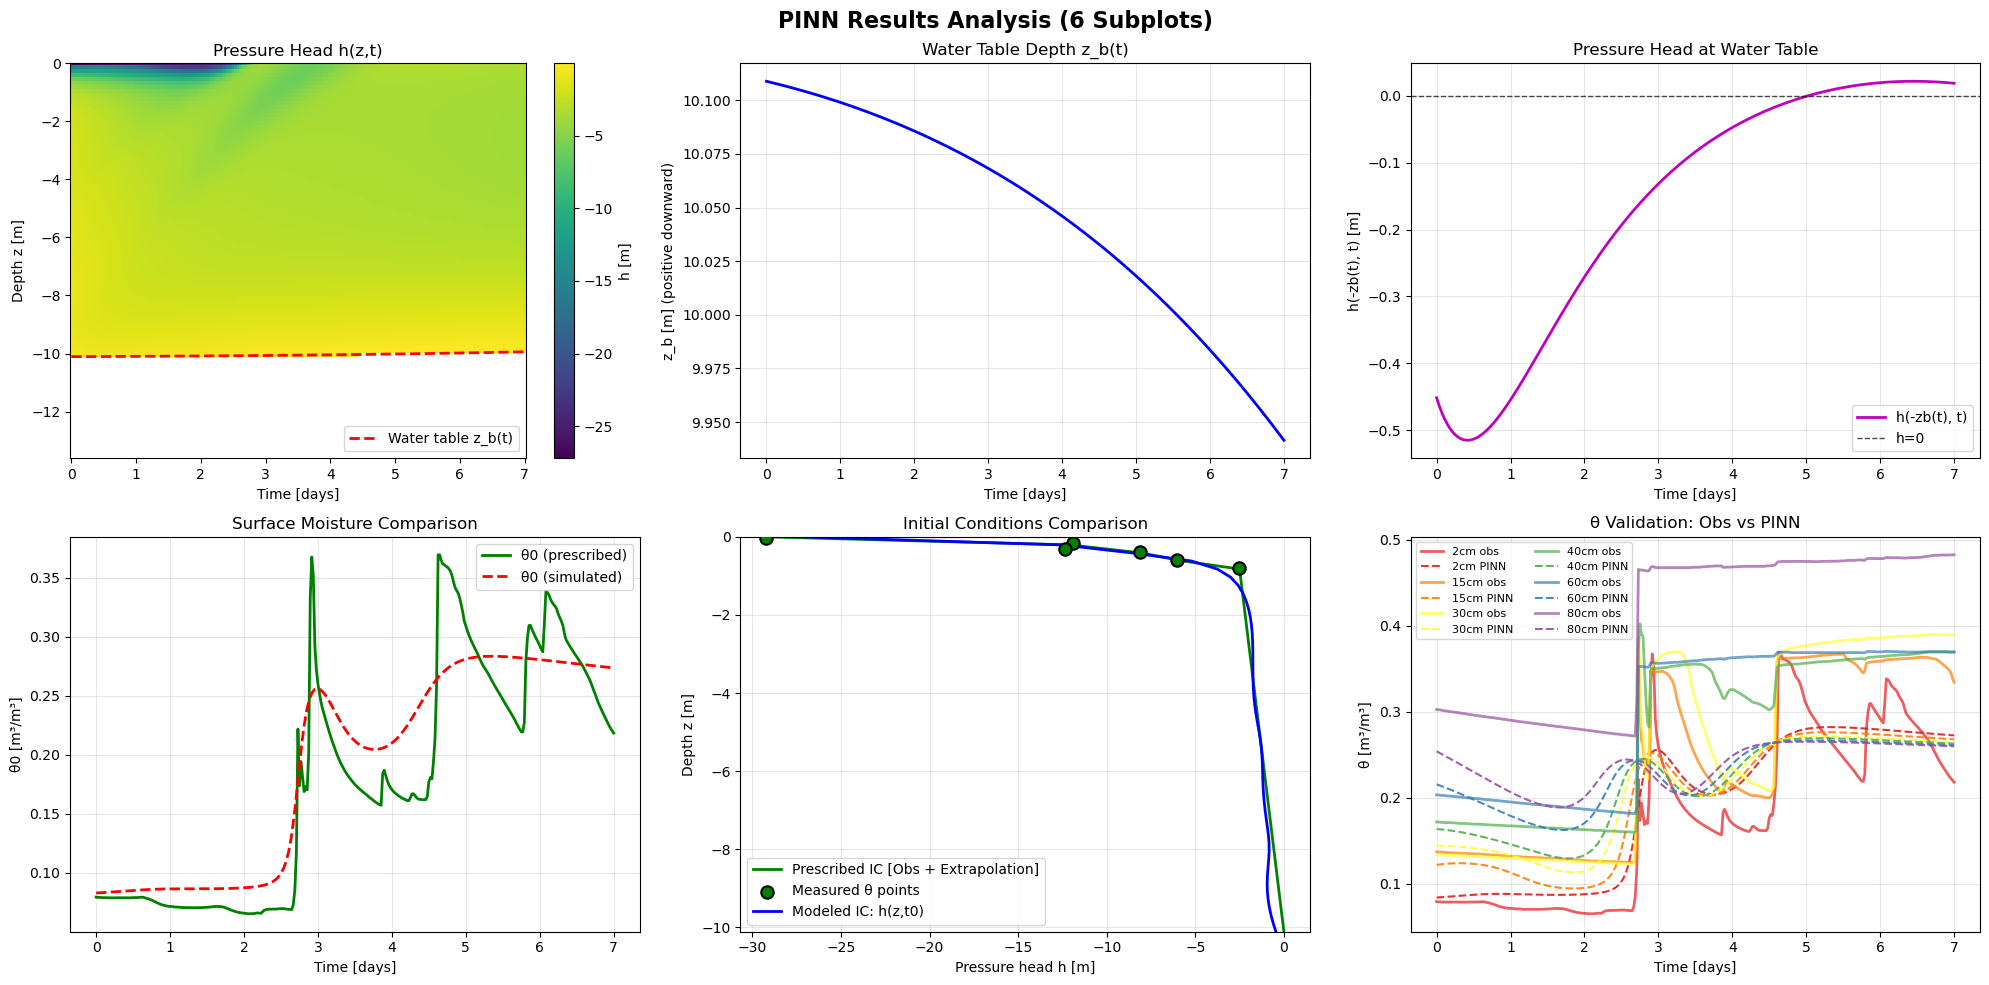


Summary Statistics:
Water table depth range: 9.942 to 10.109 m
Surface head range: -27.207 to -3.008 m
h(-zb(t), t) range: -0.514974 to 0.021791 m
Max |h(-zb(t), t)|: 0.514974 m (should be close to 0)
Max IC error: 2.000477 m

Theta Validation Statistics:
    2cm: RMSE = 0.039358 m³/m³, MAE = 0.031730 m³/m³
   15cm: RMSE = 0.062357 m³/m³, MAE = 0.052062 m³/m³
   30cm: RMSE = 0.083335 m³/m³, MAE = 0.064723 m³/m³
   40cm: RMSE = 0.083529 m³/m³, MAE = 0.071445 m³/m³
   60cm: RMSE = 0.092691 m³/m³, MAE = 0.078381 m³/m³
   80cm: RMSE = 0.180768 m³/m³, MAE = 0.163401 m³/m³

✓ Comprehensive results plotted


In [65]:
print("\n" + "=" * 70)
print("VISUALIZING RESULTS")
print("=" * 70)

# 🎨 ONE LINE to plot everything!
# Automatically:
# - Uses all available observation depths
# - Adds WTD if available
# - Formats labels correctly
plot_results(model, dataset, device=device)
plt.show()

print("\n✓ Comprehensive results plotted")

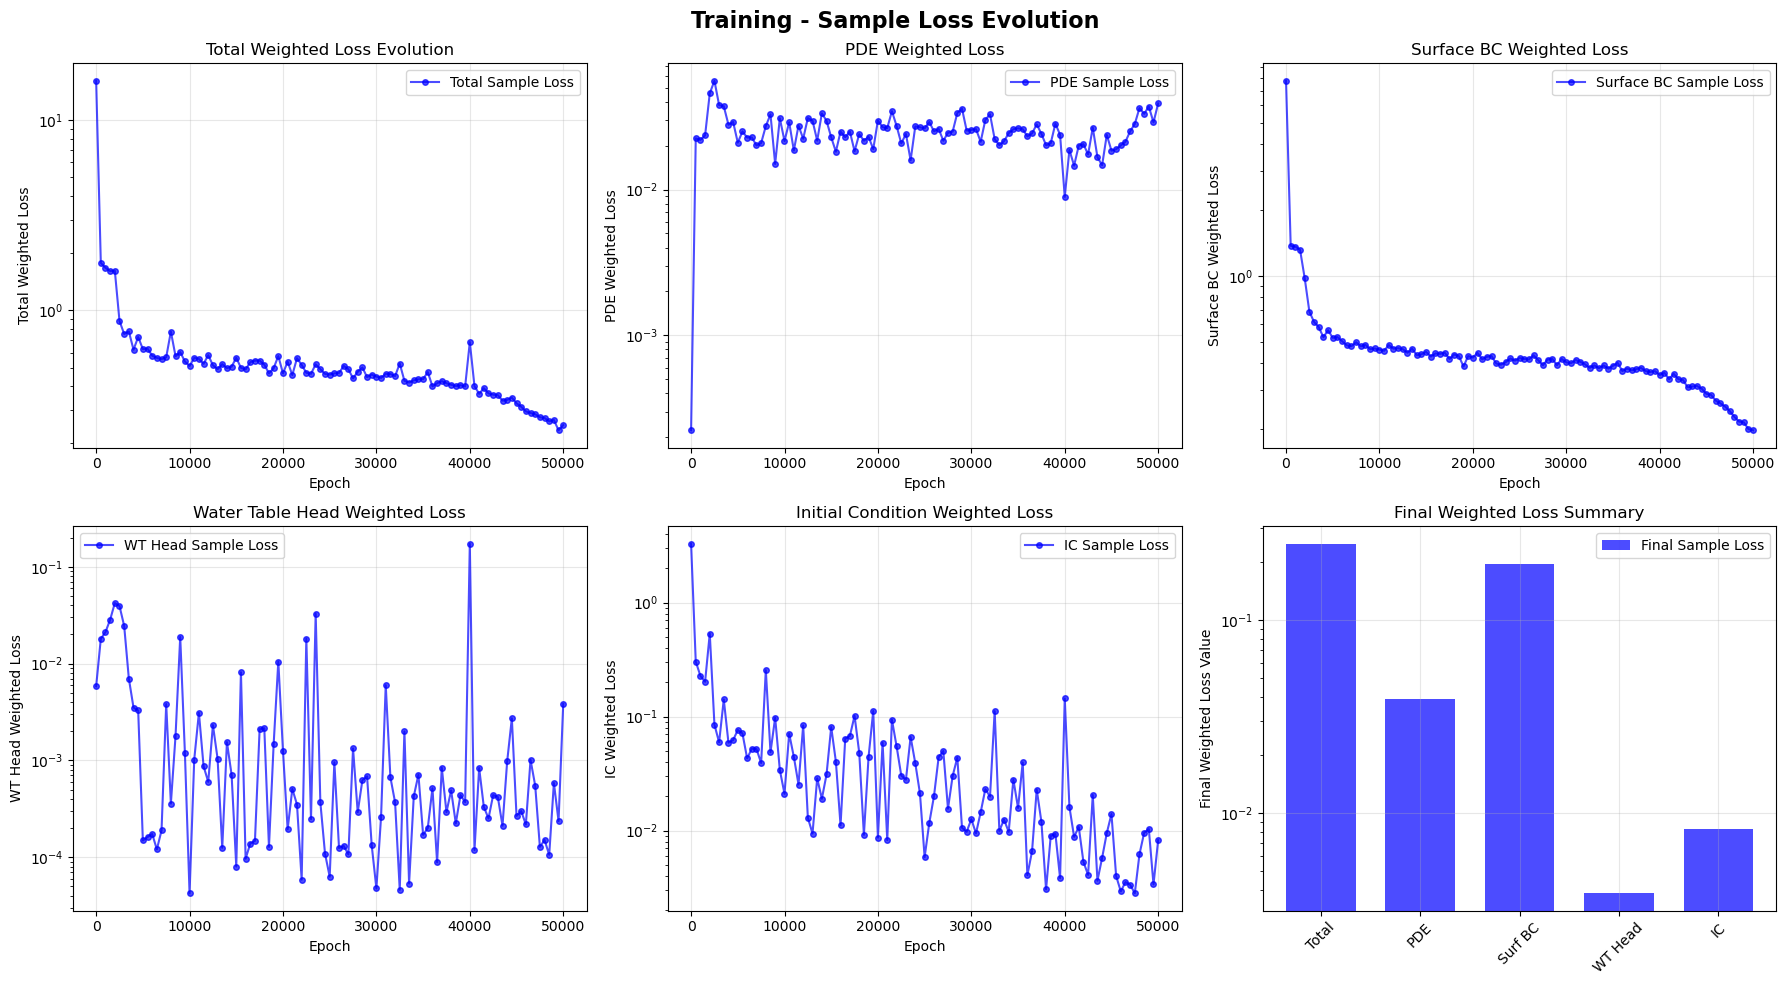


✓ Training losses plotted


In [66]:
# 📊 Plot training losses
plot_losses(losses, comps, sample_losses, sample_comps, sample_epochs)
plt.show()

print("\n✓ Training losses plotted")

In [67]:
print("Dataset Information:")
print(f"  Config: {dataset.config_path}")
print(f"  Data source: {dataset.config.data_path}")
print(f"  Date range: {dataset.config.start_date} to {dataset.config.end_date}")
print(f"\n  Observation depths: {dataset.obs_depths}")
print(f"  Total time points: {len(dataset.obs_times)}")
print(f"  Duration: {dataset.obs_times[-1]/86400:.1f} days")
print(f"\n  Boundary condition:")
print(f"    Type: {dataset.bc_type}")
print(f"    Points: {len(dataset.bc_times)}")
print(f"    Range: {dataset.bc_values.min():.4f} - {dataset.bc_values.max():.4f} m³/m³")
print(f"\n  Initial condition:")
print(f"    Type: Parabolic (automatic)")
print(f"    Computed from surface observation at t=0")
print(f"\n  Water table depth: {'Available' if dataset.has_wtd() else 'Not available'}")
print(f"\n  Training:")
print(f"    Epochs: {dataset.n_epochs}")
print(f"    Learning rate: {dataset.learning_rate}")
print(f"    Device: {dataset.device}")

Dataset Information:
  Config: ../configs/baseline.yaml
  Data source: ../data/2017_HalfHourly_UTC_ForestSite1.xlsx
  Date range: 2017-05-19 to 2017-05-26

  Observation depths: ['2cm', '15cm', '30cm', '40cm', '60cm', '80cm']
  Total time points: 337
  Duration: 7.0 days

  Boundary condition:
    Type: dirichlet
    Points: 337
    Range: 0.0652 - 0.3694 m³/m³

  Initial condition:
    Type: obs
    Profile points: 6

  Water table depth: Not available

  Training:
    Epochs: 50000
    Learning rate: 0.0001
    Device: cpu
